# Resultados y elección del modelo final · TFM Energía UCM

Reproduce, tabla a tabla y cifra a cifra, la sección de resultados y elección del modelo del informe (`docs/interpretabilidad/5_resultados_eleccion_modelo_informe.md`): por qué el modelo final es `ensemble_seleccion`, cómo se eligieron sus miembros y pesos, qué dice el test y con qué salvedades.

**Cómo funciona.** Por defecto **lee** los resultados ya calculados por `docs/interpretabilidad/tabla_decision.py` (tarda segundos) y dibuja en línea; no escribe ningún fichero ni sobrescribe los PNG del informe. Con `RECALCULAR = True` relanza antes ese script, que solo lee predicciones guardadas (no reentrena) y reescribe sus CSV y `cifras_decision.json` en `docs/interpretabilidad/`. El script reescribe también `fig_decision.png`; el notebook guarda antes los PNG de la carpeta y los restaura, de modo que las figuras no cambian.

Además de leer, el notebook **comprueba**: recalcula la tabla del informe desde las predicciones guardadas, repite el remuestreo del contraste diario, la aportación de los miembros y la correlación de errores, y busca cada cifra en el texto del informe. Todas las comprobaciones se resumen al final.

| sección | contenido | fuente |
|---|---|---|
| 0 | preparación y fuentes | — |
| 1 | tabla de decisión (la del informe y la completa) | `tabla_decision.csv`, predicciones |
| 2 | selección voraz y curva de selección | `curva_seleccion.csv` |
| 3 | contraste diario en test con IC 95 % por bloques | `contraste_diario.csv`, `mae_diario_test.csv` |
| 4 | aportación de cada miembro y correlación de errores | `aportacion_miembros.csv`, `correlacion_errores_val.csv` |
| 5 | figura MAE de validación frente a test (material de apoyo) | `tabla_decision.csv` |
| 6 | salvedades | — |

## 0 · Preparación y fuentes

Rutas, bandera `RECALCULAR`, estilo de las figuras (la paleta de las figuras del informe) y utilidades: `coma` formatea como en el informe (coma decimal y signo menos tipográfico) y `comprobar` registra cada contraste con el texto o con un recálculo.

In [1]:
import json
import os
import subprocess
import sys
from collections import Counter
from datetime import datetime
from itertools import takewhile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from matplotlib.transforms import blended_transform_factory

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DOC = REPO / "docs" / "interpretabilidad"
DIR_D = REPO / "data" / "gold" / "finales_v2_nucleo"                  # ancla D (modelo final)
DIR_S = REPO / "data" / "gold" / "finales_v2_nucleo_anclasemanal"     # ancla semanal (descartada)
PY = Path(r"C:/Users/torgi/anaconda3/python.exe")
PY = PY if PY.exists() else Path(sys.executable)

RECALCULAR = False   # True: relanza docs/interpretabilidad/tabla_decision.py antes de leer
DPI = 150            # resolución en pantalla; nada se guarda en disco

if RECALCULAR:
    pngs = {p: p.read_bytes() for p in DOC.glob("*.png")}   # tabla_decision.py reescribe fig_decision.png
    try:
        r = subprocess.run([str(PY), str(DOC / "tabla_decision.py")], cwd=REPO, capture_output=True,
                           text=True, encoding="utf-8", errors="replace",
                           env={**os.environ, "PYTHONIOENCODING": "utf-8", "MPLBACKEND": "Agg"})
        if r.returncode:
            raise RuntimeError(r.stderr[-3000:])
        print("tabla_decision.py relanzado; últimas líneas:\n", r.stdout[-800:])
    finally:
        for p, contenido in pngs.items():
            if p.read_bytes() != contenido:
                p.write_bytes(contenido)
                print("restaurada la figura", p.name)
else:
    print("RECALCULAR = False: se leen las salidas ya calculadas de", DOC.relative_to(REPO).as_posix())

# estilo: la paleta de las figuras del informe (fig_permutacion_informe.py, comportamiento.py)
TINTA, TINTA_2, EJE, REJILLA = "#0b0b0b", "#52514e", "#c3c2b7", "#e1e0d9"
BARRA, GRIS = "#2a78d6", "#9a9994"
RC = {"font.family": "DejaVu Sans", "font.size": 8, "axes.edgecolor": EJE,
      "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2, "ytick.color": TINTA,
      "axes.spines.top": False, "axes.spines.right": False}
EJE_COMA = FuncFormatter(lambda v, _: f"{v:g}".replace(".", ","))


def coma(x, dec=2, signo=False):
    """Número con el formato del informe: coma decimal y signo menos tipográfico."""
    txt = f"{x:+.{dec}f}" if signo else f"{x:.{dec}f}"
    return txt.replace("-", "\u2212").replace(".", ",")


COMPROBACIONES = []


def comprobar(nombre, ok, detalle=""):
    COMPROBACIONES.append((nombre, bool(ok)))
    print(f"[{'ok' if ok else 'FALLA'}] {nombre}" + (f" · {detalle}" if detalle else ""))

RECALCULAR = False: se leen las salidas ya calculadas de docs/interpretabilidad


In [2]:
FUENTES = {
    "informe (texto de referencia)": DOC / "5_resultados_eleccion_modelo_informe.md",
    "script de cálculo": DOC / "tabla_decision.py",
    "tabla de decisión": DOC / "tabla_decision.csv",
    "curva de selección": DOC / "curva_seleccion.csv",
    "contraste diario": DOC / "contraste_diario.csv",
    "MAE diario en test": DOC / "mae_diario_test.csv",
    "aportación de miembros": DOC / "aportacion_miembros.csv",
    "correlación de errores (val)": DOC / "correlacion_errores_val.csv",
    "cifras y verificaciones": DOC / "cifras_decision.json",
    "resumen de modelos": DIR_D / "resumen.csv",
    "meta del entrenamiento": DIR_D / "meta.json",
    "predicciones, ancla D": DIR_D,
    "predicciones, ancla semanal": DIR_S,
}
fuentes = pd.DataFrame([{"fuente": q, "ruta": p.relative_to(REPO).as_posix(), "existe": p.exists(),
                         "modificado": datetime.fromtimestamp(p.stat().st_mtime).strftime("%Y-%m-%d %H:%M")
                         if p.exists() else ""} for q, p in FUENTES.items()])
display(fuentes)
assert fuentes.existe.all(), "falta alguna fuente"

,fuente,ruta,existe,modificado
0,informe (texto de referencia),docs/interpretabilidad/5_resultados_eleccion_m...,True,2026-09-15 13:13
1,script de cálculo,docs/interpretabilidad/tabla_decision.py,True,2026-09-15 12:37
2,tabla de decisión,docs/interpretabilidad/tabla_decision.csv,True,2026-09-15 12:37
3,curva de selección,docs/interpretabilidad/curva_seleccion.csv,True,2026-09-15 12:37
4,contraste diario,docs/interpretabilidad/contraste_diario.csv,True,2026-09-15 12:37
5,MAE diario en test,docs/interpretabilidad/mae_diario_test.csv,True,2026-09-15 12:37
6,aportación de miembros,docs/interpretabilidad/aportacion_miembros.csv,True,2026-09-15 12:37
7,correlación de errores (val),docs/interpretabilidad/correlacion_errores_val...,True,2026-09-15 12:37
8,cifras y verificaciones,docs/interpretabilidad/cifras_decision.json,True,2026-09-15 12:37
9,resumen de modelos,data/gold/finales_v2_nucleo/resumen.csv,True,2026-09-14 23:36


In [3]:
tabla = pd.read_csv(DOC / "tabla_decision.csv", index_col="modelo")
curva = pd.read_csv(DOC / "curva_seleccion.csv")
contraste = pd.read_csv(DOC / "contraste_diario.csv")
diario = pd.read_csv(DOC / "mae_diario_test.csv", index_col="fecha")
aport = pd.read_csv(DOC / "aportacion_miembros.csv")
corr = pd.read_csv(DOC / "correlacion_errores_val.csv", index_col=0)
cifras = json.loads((DOC / "cifras_decision.json").read_text(encoding="utf-8"))
meta = json.loads((DIR_D / "meta.json").read_text(encoding="utf-8"))
INFORME = (DOC / "5_resultados_eleccion_modelo_informe.md").read_text(encoding="utf-8")
PESOS = meta["ensembles"]["ensemble_seleccion"]          # {miembro: peso}, fijado en validación

NOMBRE = {
    "ensemble_seleccion": "Ensemble seleccionado (modelo final)",
    "ensemble_seleccion_anclasemanal": "Ensemble seleccionado con ancla semanal (descartado)",
    "ensemble": "Media simple de 8 familias",
    "ensemble_todos": "Media simple de 12 familias (regla anterior)",
    "denso": "Red densa", "lgbm_nucleo": "LightGBM global", "lstm": "LSTM",
    "boosting": "LightGBM por hora (24 modelos)", "gru": "GRU", "seq2seq": "Seq2seq residual",
    "conv1d_lstm": "Conv1D-LSTM", "elasticnet": "Elastic Net", "simplernn": "RNN simple",
    "seq2seq_absoluto": "Seq2seq de precio absoluto", "ridge": "Ridge", "sarimax": "SARIMAX",
    "sarima": "SARIMA", "naive (persistencia)": "Persistencia (precio de D)",
}
MIEMBRO = {"lgbm_nucleo__s1": "LightGBM global", "denso__s2": "Red densa", "lstm__s1": "LSTM",
           "seq2seq_absoluto__s2": "Seq2seq precio absoluto", "gru__s2": "GRU",
           "seq2seq__s1": "Seq2seq residual"}
assert set(MIEMBRO) == set(PESOS), "los miembros del meta no son los esperados"

print(f"tabla de decisión: {len(tabla)} filas · curva: {len(curva)} pasos (ancla D y semanal) · "
      f"contraste: {len(contraste)} rivales · días de test: {len(diario)}")
print(f"validación {meta['dias_val']} días · test {meta['dias_test']} días · persistencia: "
      f"val {meta['naive_val_MAE']:.3f}, test {meta['naive_test_MAE']:.3f} €/MWh")

tabla de decisión: 18 filas · curva: 60 pasos (ancla D y semanal) · contraste: 8 rivales · días de test: 212
validación 365 días · test 212 días · persistencia: val 19.948, test 16.721 €/MWh


## 1 · Tabla de decisión

### 1.1 · La tabla del informe (8 filas)

Los candidatos a modelo final. **Cómo leerla:** MAE en €/MWh (menos es mejor), en validación 2025 (365 días) y en test enero-julio de 2026 (212 días). La **captura** es la parte del spread diario que se obtendría cargando en el valle predicho y descargando en el pico predicho; el **pico ±1 h** es el porcentaje de días en que la hora más cara predicha cae a menos de una hora de la real; la **mejora frente a persistencia** es la reducción relativa del MAE de test respecto a repetir el precio de D. Las tres últimas, en test. Modelos individuales: media de 3 semillas; medias simples: mejor semilla de cada familia.

`tabla_decision.csv` guarda las cifras con 3 decimales, que no bastan para redondear sin ambigüedad (12,165 puede ser 12,16 o 12,17). Por eso la celda recalcula las 8 filas **desde las predicciones guardadas** con la misma definición de métricas que `scripts/entrenar_finales.py`, comprueba que coinciden con el CSV y compara la tabla formateada, celda a celda, con la del informe.

In [4]:
def leer(carpeta, nombre):
    return pd.read_csv(carpeta / f"{nombre}.csv", index_col=0).to_numpy()


def metricas(y, p):
    """Misma definición que `metricas` en scripts/entrenar_finales.py (MAE, captura, pico ±1 h)."""
    n = np.arange(len(y))
    captura = (y[n, p.argmax(1)] - y[n, p.argmin(1)]) / np.maximum(y.max(1) - y.min(1), .1)
    return {"MAE": float(np.abs(p - y).mean()), "captura": float(100 * captura.mean()),
            "pico": float(100 * (np.abs(y.argmax(1) - p.argmax(1)) <= 1).mean())}


YV, YT = leer(DIR_D, "ref_val_real"), leer(DIR_D, "ref_test_real")
comprobar("el precio real es el mismo en las carpetas de ancla D y semanal",
          np.allclose(YV, leer(DIR_S, "ref_val_real")) and np.allclose(YT, leer(DIR_S, "ref_test_real")))

# el ensemble con ancla semanal no guarda predicciones: se rehace con su curva, hasta su mínimo
cs = curva[curva.ancla == "semanal"].reset_index(drop=True)
PESOS_S = Counter(cs.loc[:cs.MAE_val.idxmin(), "entra"])


def mezcla(carpeta, parte, pesos):
    tot = sum(pesos.values())
    return sum(leer(carpeta, f"pred_{parte}_{k}") * w / tot for k, w in pesos.items())


def medir(clave):
    if clave == "naive (persistencia)":
        mv, mt = [metricas(YV, leer(DIR_D, "ref_val_naive"))], [metricas(YT, leer(DIR_D, "ref_test_naive"))]
    elif clave == "ensemble_seleccion_anclasemanal":
        mv, mt = [metricas(YV, mezcla(DIR_S, "val", PESOS_S))], [metricas(YT, mezcla(DIR_S, "test", PESOS_S))]
    elif clave.startswith("ensemble"):
        mv = [metricas(YV, leer(DIR_D, f"pred_val_{clave}"))]
        mt = [metricas(YT, leer(DIR_D, f"pred_test_{clave}"))]
    else:                                   # familia: media de las métricas de sus semillas
        sem = sorted(p.stem.rsplit("__s", 1)[1] for p in DIR_D.glob(f"pred_val_{clave}__s*.csv"))
        mv = [metricas(YV, leer(DIR_D, f"pred_val_{clave}__s{s}")) for s in sem]
        mt = [metricas(YT, leer(DIR_D, f"pred_test_{clave}__s{s}")) for s in sem]
    return {"MAE_val": np.mean([m["MAE"] for m in mv]), "MAE_test": np.mean([m["MAE"] for m in mt]),
            "captura_test": np.mean([m["captura"] for m in mt]), "pico_1h": np.mean([m["pico"] for m in mt])}


FILAS_INFORME = ["ensemble_seleccion", "ensemble_seleccion_anclasemanal", "ensemble", "ensemble_todos",
                 "denso", "lgbm_nucleo", "gru", "naive (persistencia)"]
rec = pd.DataFrame({k: medir(k) for k in FILAS_INFORME}).T
rec["mejora_%"] = 100 * (1 - rec.MAE_test / rec.loc["naive (persistencia)", "MAE_test"])

# 1) lo recalculado coincide con tabla_decision.csv (que redondea a 3 y 2 decimales)
t = tabla.loc[FILAS_INFORME]
dif_mae = (rec[["MAE_val", "MAE_test"]] - t[["MAE_val", "MAE_test"]]).abs().max().max()
dif_pct = (rec[["captura_test", "pico_1h"]] - t[["captura_test", "pico_1h"]]).abs().max().max()
comprobar("MAE recalculado desde predicciones = tabla_decision.csv", dif_mae <= 0.0006, f"máx. {dif_mae:.4f}")
comprobar("captura y pico recalculados = tabla_decision.csv", dif_pct <= 0.006, f"máx. {dif_pct:.4f}")
comprobar("mejora frente a persistencia = tabla_decision.csv",
          (rec["mejora_%"].round(1) == -t["vs_naive_test_%"]).all())

# 2) la tabla formateada coincide celda a celda con la del informe
COLS = ["Modelo", "MAE val", "MAE test", "Captura (%)", "Pico ±1 h (%)", "Mejora frente a persistencia (%)"]
tabla_x = pd.DataFrame(
    [[NOMBRE[k], coma(r.MAE_val), coma(r.MAE_test), coma(r.captura_test, 1), coma(r.pico_1h, 1),
      "—" if k == "naive (persistencia)" else coma(r["mejora_%"], 1)] for k, r in rec.iterrows()],
    columns=COLS)
lineas = INFORME.splitlines()
i0 = next(i for i, l in enumerate(lineas) if l.startswith("| Modelo"))
tabla_md = pd.DataFrame([[c.strip().replace("**", "") for c in l.strip().strip("|").split("|")]
                         for l in takewhile(lambda l: l.startswith("|"), lineas[i0 + 2:])], columns=COLS)
distintas = (tabla_x != tabla_md)
comprobar("tabla del informe reproducida celda a celda (8 filas × 6 columnas)", not distintas.values.any(),
          "" if not distintas.values.any() else str(tabla_x[distintas.any(axis=1)].to_dict("records")))
display(tabla_x.style.hide(axis="index").set_properties(subset=pd.IndexSlice[0, :], **{"font-weight": "bold"}))

[ok] el precio real es el mismo en las carpetas de ancla D y semanal
[ok] MAE recalculado desde predicciones = tabla_decision.csv · máx. 0.0005
[ok] captura y pico recalculados = tabla_decision.csv · máx. 0.0057
[ok] mejora frente a persistencia = tabla_decision.csv
[ok] tabla del informe reproducida celda a celda (8 filas × 6 columnas)


Modelo,MAE val,MAE test,Captura (%),Pico ±1 h (%),Mejora frente a persistencia (%)
Ensemble seleccionado (modelo final),"11,73","11,72","92,6","76,4","29,9"
Ensemble seleccionado con ancla semanal (descartado),"11,83","12,17","92,2","78,3","27,2"
Media simple de 8 familias,"12,52","12,03","90,5","77,4","28,0"
Media simple de 12 familias (regla anterior),"12,63","11,88","92,9","78,3","28,9"
Red densa,"12,94","13,29","88,5","74,7","20,5"
LightGBM global,"13,06","14,25","90,5","75,0","14,8"
GRU,"14,13","13,19","89,6","77,0","21,1"
Persistencia (precio de D),"19,95","16,72","86,1","67,5",—


In [5]:
sel, nv = rec.loc["ensemble_seleccion"], rec.loc["naive (persistencia)"]
print("Cifras clave (para contrastar con el informe)")
print(f"  modelo final: MAE val {coma(sel.MAE_val, 3)} · test {coma(sel.MAE_test, 3)} €/MWh · captura "
      f"{coma(sel.captura_test, 1)} % · pico ±1 h {coma(sel.pico_1h, 1)} % · mejora {coma(sel['mejora_%'], 1)} %")
print(f"  persistencia: MAE val {coma(nv.MAE_val, 3)} · test {coma(nv.MAE_test, 3)} €/MWh")
print(f"  ancla semanal (descartada): val {coma(rec.loc['ensemble_seleccion_anclasemanal', 'MAE_val'], 3)} · "
      f"test {coma(rec.loc['ensemble_seleccion_anclasemanal', 'MAE_test'], 3)}")
print(f"  puesto del modelo final: {tabla.loc['ensemble_seleccion', 'rango_val']}.º en validación y "
      f"{tabla.loc['ensemble_seleccion', 'rango_test']}.º en test, de {len(tabla)}")
comprobar("el modelo final es 1.º en validación y en test",
          tabla.loc["ensemble_seleccion", ["rango_val", "rango_test"]].tolist() == [1, 1])
comprobar(f"«{coma(sel['mejora_%'], 1)} %» y «{coma(sel.MAE_test)}» aparecen en el informe",
          f"{coma(sel['mejora_%'], 1)} %" in INFORME and coma(sel.MAE_test) in INFORME)

Cifras clave (para contrastar con el informe)
  modelo final: MAE val 11,732 · test 11,724 €/MWh · captura 92,6 % · pico ±1 h 76,4 % · mejora 29,9 %
  persistencia: MAE val 19,948 · test 16,721 €/MWh
  ancla semanal (descartada): val 11,833 · test 12,165
  puesto del modelo final: 1.º en validación y 1.º en test, de 18
[ok] el modelo final es 1.º en validación y en test
[ok] «29,9 %» y «11,72» aparecen en el informe


### 1.2 · La tabla completa (18 filas)

Todo lo que guarda `tabla_decision.csv`: los cuatro ensembles, las 13 familias ordenadas por MAE de validación y la persistencia. **Columnas añadidas al resumen:** `representante_val` es la semilla con menor MAE de validación de cada familia (la que compite en la selección voraz), con sus MAE; `miembro_seleccion`, `peso` y `peso_de_30` dicen si entra en el ensemble final y con qué peso; `rango_val` y `rango_test` son los puestos (1 = mejor). La descripción se sustituye por el nombre usado en el informe.

In [6]:
completa = tabla.drop(columns="descripcion")
completa.insert(0, "nombre", [NOMBRE[k] for k in completa.index])
with pd.option_context("display.max_columns", None, "display.width", 250):
    display(completa)

fam = tabla[~tabla.tipo.isin(["ensemble", "referencia"])]
nv_val, nv_test = tabla.loc["naive (persistencia)", ["MAE_val", "MAE_test"]]
baten_val = fam[fam.MAE_val < nv_val]
solo_val = baten_val[baten_val.MAE_test > nv_test]
print(f"familias que baten a la persistencia en validación: {len(baten_val)} de {len(fam)} "
      f"(fuera: {', '.join(NOMBRE[k] for k in fam.index.difference(baten_val.index))})")
print("de ellas, no la baten en test:", ", ".join(f"{NOMBRE[k]} (val {coma(r.MAE_val)}, test {coma(r.MAE_test)})"
                                                   for k, r in solo_val.iterrows()))
comprobar("la media de 12 familias son las que baten a la persistencia en validación",
          len(baten_val) == tabla.loc["ensemble_todos", "n"] == 12)
comprobar("la media de 8 familias son las 7 redes y LightGBM por hora",
          (fam.tipo == "red").sum() + 1 == tabla.loc["ensemble", "n"] == 8)
texto = f"{coma(solo_val.loc['ridge', 'MAE_test'])} y {coma(solo_val.loc['sarimax', 'MAE_test'])} frente a {coma(nv_test)}"
comprobar(f"«{texto}» aparece en el informe", texto in INFORME)

,nombre,tipo,n,MAE_val,sd_val,MAE_test,sd_test,captura_test,pico_1h,vs_naive_test_%,representante_val,MAE_val_representante,MAE_test_representante,miembro_seleccion,peso,peso_de_30,rango_val,rango_test
modelo,,,,,,,,,,,,,,,,,,
ensemble_seleccion,Ensemble seleccionado (modelo final),ensemble,6,11.732,NaN,11.724,NaN,92.57,76.42,-29.9,NaN,NaN,NaN,-,1.0000,30/30,1,1
ensemble,Media simple de 8 familias,ensemble,8,12.519,NaN,12.034,NaN,90.55,77.36,-28.0,NaN,NaN,NaN,-,NaN,NaN,3,3
ensemble_todos,Media simple de 12 familias (regla anterior),ensemble,12,12.635,NaN,11.883,NaN,92.89,78.30,-28.9,NaN,NaN,NaN,-,NaN,NaN,4,2
ensemble_seleccion_anclasemanal,Ensemble seleccionado con ancla semanal (desca...,ensemble,4,11.833,NaN,12.165,NaN,92.18,78.30,-27.2,NaN,NaN,NaN,-,NaN,NaN,2,4
denso,Red densa,red,3,12.935,0.147,13.286,0.877,88.49,74.68,-20.5,denso__s2,12.843,13.466,si,0.3333,10/30,5,6
lgbm_nucleo,LightGBM global,arbol,3,13.061,0.073,14.248,0.085,90.52,75.00,-14.8,lgbm_nucleo__s1,13.008,14.164,si,0.3667,11/30,6,11
lstm,LSTM,red,3,13.457,0.141,14.711,0.978,87.32,72.48,-12.0,lstm__s1,13.296,15.778,si,0.1000,3/30,7,13
boosting,LightGBM por hora (24 modelos),arbol,3,13.714,0.052,14.550,0.055,88.63,76.57,-13.0,boosting__s0,13.661,14.533,no,0.0000,NaN,8,12
gru,GRU,red,3,14.132,0.127,13.188,0.265,89.63,77.04,-21.1,gru__s2,14.052,12.886,si,0.0667,2/30,9,5


familias que baten a la persistencia en validación: 12 de 13 (fuera: SARIMA)
de ellas, no la baten en test: Ridge (val 17,58, test 19,18), SARIMAX (val 18,01, test 21,45)
[ok] la media de 12 familias son las que baten a la persistencia en validación
[ok] la media de 8 familias son las 7 redes y LightGBM por hora
[ok] «19,18 y 21,45 frente a 16,72» aparece en el informe


## 2 · Cómo se eligió: selección voraz y curva de selección

Miembros y pesos salen **solo de validación**. Los candidatos son la mejor semilla de cada familia en validación. Se parte de un ensemble vacío y, en cada uno de los 30 pasos, entra el candidato que más reduce el MAE de validación de la media; puede repetir (selección hacia delante **con reemplazo**), y el número de veces que entra fija su peso. Se queda el prefijo con menor MAE.

La tabla resume cada miembro: veces que entra, peso, paso en que entra por primera vez y su MAE solo. Después se comprueba que los pesos que salen de la curva son los del `meta.json` y los del informe.

In [7]:
cd = curva[curva.ancla == "D"].reset_index(drop=True)
cuenta = Counter(cd.loc[:cd.MAE_val.idxmin(), "entra"])
orden = sorted(PESOS, key=PESOS.get, reverse=True)
solo = aport.set_index("quitado")
miembros = pd.DataFrame({
    "miembro": [MIEMBRO[k] for k in orden], "clave": orden,
    "veces que entra": [cuenta[k] for k in orden], "peso": [f"{cuenta[k]}/30" for k in orden],
    "peso (meta.json)": [PESOS[k] for k in orden],
    "primer paso": [int(cd.paso[cd.entra == k].min()) for k in orden],
    "MAE val solo": [solo.loc[k, "MAE_val_miembro_solo"] for k in orden],
    "MAE test solo": [solo.loc[k, "MAE_test_miembro_solo"] for k in orden]})
display(miembros.style.hide(axis="index").format({"peso (meta.json)": "{:.4f}", "MAE val solo": "{:.3f}",
                                                  "MAE test solo": "{:.3f}"}))

comprobar("pesos de la curva = meta.json", all(round(PESOS[k] * 30) == v for k, v in cuenta.items())
          and sum(cuenta.values()) == 30)
comprobar("pesos de la curva = peso_de_30 de tabla_decision.csv",
          all(tabla.loc[k.rsplit("__s", 1)[0], "peso_de_30"] == f"{v}/30" for k, v in cuenta.items()))
NOMBRE_TEXTO = {"lgbm_nucleo__s1": "LightGBM global", "denso__s2": "red densa", "lstm__s1": "LSTM",
                "seq2seq_absoluto__s2": "seq2seq de precio absoluto", "gru__s2": "GRU",
                "seq2seq__s1": "seq2seq residual"}
partes = [f"{NOMBRE_TEXTO[k]} ({cuenta[k]}/30)" for k in orden]
texto = ", ".join(partes[:-1]) + " y " + partes[-1]
comprobar("la lista de miembros y pesos aparece en el informe", texto in INFORME, texto)

y = cd.MAE_val.to_numpy()
imin = int(np.argmin(y))
print(f"\ncurva (ancla D): paso 1 {coma(y[0], 3)} (red densa sola) · paso 2 {coma(y[1], 3)} · "
      f"paso 10 {coma(y[9], 3)} · paso 20 {coma(y[19], 3)} · paso 30 {coma(y[29], 3)}")
print(f"mínimo {coma(y[imin], 3)} en el paso {imin + 1}; entre los pasos 10 y 30 solo baja "
      f"{coma(y[9] - y[29], 4)} €/MWh: la curva es plana y los pesos pequeños están poco determinados")
comprobar("curva = cifras_decision.json", cifras["curva_ancla_D"]["paso_minimo"] == imin + 1
          and abs(cifras["curva_ancla_D"]["MAE_paso_10"] - y[9]) < 1e-9)
tot_s = sum(PESOS_S.values())
print(f"ancla semanal (descartada): mínimo en el paso {cs.MAE_val.idxmin() + 1}; pesos "
      + ", ".join(f"{k} {v}/{tot_s}" for k, v in PESOS_S.most_common()))
comprobar("pesos del ancla semanal = cifras_decision.json",
          all(abs(cifras["ancla_semanal"]["pesos"][k] - v / tot_s) < 1e-4 for k, v in PESOS_S.items()))

miembro,clave,veces que entra,peso,peso (meta.json),primer paso,MAE val solo,MAE test solo
LightGBM global,lgbm_nucleo__s1,11,11/30,0.3667,2,13.008,14.164
Red densa,denso__s2,10,10/30,0.3333,1,12.843,13.466
LSTM,lstm__s1,3,3/30,0.1000,3,13.296,15.778
Seq2seq precio absoluto,seq2seq_absoluto__s2,3,3/30,0.1000,5,15.401,15.276
GRU,gru__s2,2,2/30,0.0667,8,14.052,12.886
Seq2seq residual,seq2seq__s1,1,1/30,0.0333,17,13.966,13.277


[ok] pesos de la curva = meta.json
[ok] pesos de la curva = peso_de_30 de tabla_decision.csv
[ok] la lista de miembros y pesos aparece en el informe · LightGBM global (11/30), red densa (10/30), LSTM (3/30), seq2seq de precio absoluto (3/30), GRU (2/30) y seq2seq residual (1/30)

curva (ancla D): paso 1 12,843 (red densa sola) · paso 2 11,889 · paso 10 11,736 · paso 20 11,734 · paso 30 11,732
mínimo 11,732 en el paso 30; entre los pasos 10 y 30 solo baja 0,0041 €/MWh: la curva es plana y los pesos pequeños están poco determinados
[ok] curva = cifras_decision.json
ancla semanal (descartada): mínimo en el paso 23; pesos lgbm_nucleo__s1 9/23, denso__s1 7/23, seq2seq_absoluto__s2 4/23, lstm__s1 3/23
[ok] pesos del ancla semanal = cifras_decision.json


**La figura.** Arriba, el MAE de validación del ensemble tras cada paso, con dos referencias: la media simple de 8 familias y los seis miembros a pesos iguales. En medio, el mismo recorrido ampliado desde el paso 5, donde se ve que la curva es casi plana y que el mínimo cae en el último paso permitido. Abajo, qué miembro entra en cada paso (punto azul) y, a la derecha, las veces que entra, que es su peso sobre 30.

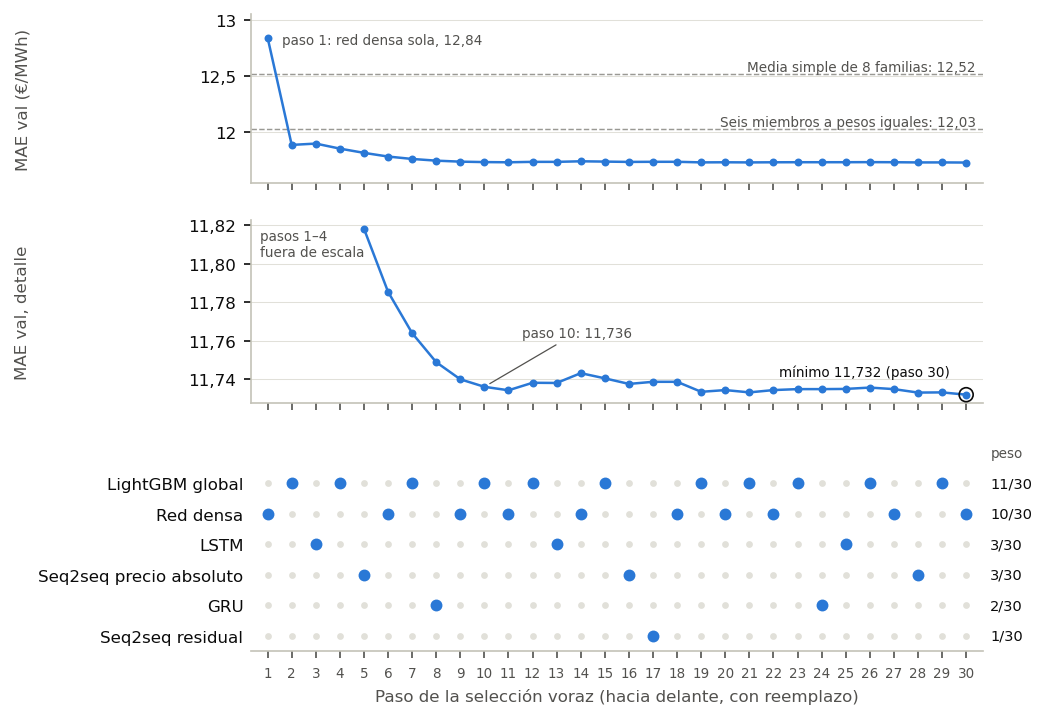

In [8]:
x = cd.paso.to_numpy()
with plt.rc_context(RC):
    fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(16 / 2.54, 14 / 2.54), dpi=DPI, sharex=True,
                                     gridspec_kw={"height_ratios": [1.2, 1.3, 1.5], "hspace": 0.2})
    # a) curva completa
    refs = {"Media simple de 8 familias": tabla.loc["ensemble", "MAE_val"],
            "Seis miembros a pesos iguales": solo.iloc[-1]["MAE_val"]}
    for txt, v in refs.items():
        a1.axhline(v, color=GRIS, lw=0.7, ls="--", zorder=1)
        a1.text(30.4, v, f"{txt}: {coma(v)}", ha="right", va="bottom", fontsize=6.5, color=TINTA_2)
    a1.plot(x, y, color=BARRA, lw=1.2, marker="o", ms=2.8, zorder=3)
    a1.annotate(f"paso 1: red densa sola, {coma(y[0])}", (1, y[0]), xytext=(7, -1),
                textcoords="offset points", ha="left", va="center", fontsize=6.5, color=TINTA_2)
    a1.set_ylim(11.55, 13.05)
    a1.set_ylabel("MAE val (€/MWh)")
    # b) detalle desde el paso 5
    m = x >= 5
    a2.plot(x[m], y[m], color=BARRA, lw=1.2, marker="o", ms=2.8, zorder=3)
    a2.scatter([x[imin]], [y[imin]], s=45, facecolor="none", edgecolor=TINTA, lw=0.8, zorder=4)
    a2.annotate(f"mínimo {coma(y[imin], 3)} (paso {imin + 1})", (x[imin], y[imin]), xytext=(-8, 9),
                textcoords="offset points", ha="right", fontsize=6.5, color=TINTA)
    a2.annotate(f"paso 10: {coma(y[9], 3)}", (10, y[9]), xytext=(18, 26), textcoords="offset points",
                ha="left", va="center", fontsize=6.5, color=TINTA_2,
                arrowprops={"arrowstyle": "-", "color": TINTA_2, "lw": 0.6, "shrinkA": 1, "shrinkB": 3})
    a2.text(0.7, y[m].max(), "pasos 1–4\nfuera de escala", fontsize=6.5, color=TINTA_2, va="top")
    a2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2f}".replace(".", ",")))
    a2.set_ylabel("MAE val, detalle")
    for a in (a1, a2):
        a.grid(axis="y", color=REJILLA, lw=0.5, zorder=0)
    a1.yaxis.set_major_formatter(EJE_COMA)
    # c) quién entra en cada paso
    for fila, k in enumerate(orden):
        pk = cd.paso[cd.entra == k]
        a3.scatter(x, np.full(len(x), fila), s=5, color=REJILLA, zorder=1)
        a3.scatter(pk, np.full(len(pk), fila), s=22, color=BARRA, zorder=2)
        a3.text(31.0, fila, f"{cuenta[k]}/30", va="center", ha="left", fontsize=7, color=TINTA)
    a3.text(31.0, -1, "peso", va="center", ha="left", fontsize=6.5, color=TINTA_2)
    a3.set_yticks(range(len(orden)), [MIEMBRO[k] for k in orden])
    a3.set_ylim(len(orden) - 0.5, -1.4)
    a3.set_xticks(x)
    a3.set_xlim(0.3, 30.7)
    a3.tick_params(axis="x", labelsize=6.5)
    a3.tick_params(axis="y", length=0)
    a3.spines["left"].set_visible(False)
    a3.set_xlabel("Paso de la selección voraz (hacia delante, con reemplazo)")
    fig.align_ylabels()
    plt.show()

## 3 · Contraste diario en test con IC 95 % por bloques

¿La ventaja del ensemble en test es real o suerte de 212 días? Para cada día se calcula el MAE de las 24 horas del ensemble y de cada rival, y se promedia la diferencia **rival − ensemble** (positiva: gana el ensemble). El intervalo al 95 % sale de un **bootstrap de bloques móviles de 7 días** (5000 remuestreos, semilla 20260915), que respeta la dependencia entre días seguidos; es de percentiles.

La celda repite el remuestreo desde `mae_diario_test.csv` con la misma semilla y construcción de índices que `tabla_decision.py` y comprueba que da los intervalos del CSV; después busca cada intervalo en el texto del informe.

In [9]:
ETQ_RIVAL = {"naive (persistencia)": "Persistencia (precio de D)",
             "lgbm_nucleo__s1": "LightGBM global, semilla miembro (11/30)",
             "lgbm_nucleo_media3": "LightGBM global, media de 3 semillas",
             "gru__s2": "GRU, semilla miembro (2/30)", "gru_media3": "GRU, media de 3 semillas",
             "ensemble_seleccion_anclasemanal": "Seleccionado con ancla semanal",
             "ensemble": "Media simple de 8 familias", "ensemble_todos": "Media simple de 12 familias"}
c = contraste.set_index("rival")

# repetición del bootstrap (mismos parámetros y orden de operaciones que tabla_decision.py)
B, BLOQUE, SEMILLA_BOOT = 5000, 7, 20260915
comprobar("parámetros del bootstrap = los del CSV",
          c.bootstrap.iloc[0] == f"bloques moviles de {BLOQUE} dias, {B} remuestreos, semilla {SEMILLA_BOOT}")
mae_sel = diario["ensemble_seleccion"].to_numpy()
n = len(mae_sel)
rng = np.random.default_rng(SEMILLA_BOOT)
inicios = rng.integers(0, n - BLOQUE + 1, size=(B, int(np.ceil(n / BLOQUE))))
idx = (inicios[:, :, None] + np.arange(BLOQUE)).reshape(B, -1)[:, :n]
rep = {}
for k in c.index:
    dif = diario[k].to_numpy() - mae_sel
    bd = dif[idx].mean(1)
    rep[k] = {"dif": dif.mean(), "inf": np.percentile(bd, 2.5), "sup": np.percentile(bd, 97.5),
              "gana": 100 * (dif > 0).mean()}
rep = pd.DataFrame(rep).T
err = max((rep.dif - c.dif_media_rival_menos_sel).abs().max(), (rep.inf - c.IC95_inf).abs().max(),
          (rep.sup - c.IC95_sup).abs().max())
comprobar("bootstrap repetido desde mae_diario_test.csv = contraste_diario.csv", err < 0.002,
          f"diferencia máxima {err:.4f} €/MWh (el MAE diario se guarda con 4 decimales)")
comprobar("% de días que gana el ensemble = CSV", (rep.gana.round(1) - c.pct_dias_gana_sel).abs().max() < 0.06)

vista = pd.DataFrame({
    "rival": [ETQ_RIVAL.get(k, k) for k in c.index], "MAE test rival": c.MAE_test_rival,
    "diferencia (rival − ensemble)": c.dif_media_rival_menos_sel, "IC 95 % inf.": c.IC95_inf,
    "IC 95 % sup.": c.IC95_sup, "% días que gana el ensemble": c.pct_dias_gana_sel,
    "mejora relativa (%)": c["mejora_relativa_%"], "significativa": c.IC_excluye_0.map({True: "sí", False: "no"})})
display(vista.style.hide(axis="index").format(precision=3, subset=list(vista.columns[1:5]))
        .format(precision=1, subset=list(vista.columns[5:7])))


def intervalo(k):
    r = c.loc[k]
    return f"{coma(r.dif_media_rival_menos_sel, signo=True)} [{coma(r.IC95_inf)}; {coma(r.IC95_sup)}]"


print(f"MAE de test del ensemble: {coma(c.MAE_test_seleccion.iloc[0], 3)} €/MWh · {n} días")
EN_INFORME = ["naive (persistencia)", "lgbm_nucleo__s1", "gru__s2", "ensemble_seleccion_anclasemanal",
              "ensemble_todos", "ensemble"]
for k in c.index:
    if k in EN_INFORME:
        comprobar(f"{ETQ_RIVAL[k]}: «{intervalo(k)}» en el informe", intervalo(k) in INFORME)
    else:
        print(f"[—] {ETQ_RIVAL[k]}: {intervalo(k)} (no citado en el informe corto)")
texto = f"({coma(c.loc['lgbm_nucleo__s1', 'MAE_test_rival'])} y {coma(c.loc['gru__s2', 'MAE_test_rival'])})"
comprobar(f"MAE de test de las semillas miembro «{texto}» en el informe", texto in INFORME)
comprobar("«siete días» y «5000 réplicas» en el informe", "siete días" in INFORME and f"{B} réplicas" in INFORME)

[ok] parámetros del bootstrap = los del CSV
[ok] bootstrap repetido desde mae_diario_test.csv = contraste_diario.csv · diferencia máxima 0.0005 €/MWh (el MAE diario se guarda con 4 decimales)
[ok] % de días que gana el ensemble = CSV


rival,MAE test rival,diferencia (rival − ensemble),IC 95 % inf.,IC 95 % sup.,% días que gana el ensemble,mejora relativa (%),significativa
Media simple de 12 familias,11.883,0.159,-0.283,0.762,58.5,1.3,no
Media simple de 8 familias,12.034,0.310,-0.046,0.767,56.1,2.6,no
"GRU, semilla miembro (2/30)",12.886,1.162,0.657,1.816,63.7,9.0,sí
"GRU, media de 3 semillas",12.687,0.963,0.416,1.718,62.3,7.6,sí
"LightGBM global, semilla miembro (11/30)",14.164,2.441,1.488,3.461,71.7,17.2,sí
"LightGBM global, media de 3 semillas",14.159,2.435,1.468,3.530,70.3,17.2,sí
Persistencia (precio de D),16.721,4.998,3.934,6.337,69.3,29.9,sí
Seleccionado con ancla semanal,12.165,0.442,0.142,0.775,58.5,3.6,sí


MAE de test del ensemble: 11,724 €/MWh · 212 días
[ok] Media simple de 12 familias: «+0,16 [−0,28; 0,76]» en el informe
[ok] Media simple de 8 familias: «+0,31 [−0,05; 0,77]» en el informe
[ok] GRU, semilla miembro (2/30): «+1,16 [0,66; 1,82]» en el informe
[—] GRU, media de 3 semillas: +0,96 [0,42; 1,72] (no citado en el informe corto)
[ok] LightGBM global, semilla miembro (11/30): «+2,44 [1,49; 3,46]» en el informe
[—] LightGBM global, media de 3 semillas: +2,44 [1,47; 3,53] (no citado en el informe corto)
[ok] Persistencia (precio de D): «+5,00 [3,93; 6,34]» en el informe
[ok] Seleccionado con ancla semanal: «+0,44 [0,14; 0,78]» en el informe
[ok] MAE de test de las semillas miembro «(14,16 y 12,89)» en el informe
[ok] «siete días» y «5000 réplicas» en el informe


**Cómo leer la figura.** Cada fila es un rival; el punto es la diferencia media de MAE diario (rival − ensemble) y la barra, su IC al 95 %. A la derecha de la línea vertical gana el ensemble. Punto azul relleno: el intervalo no toca el cero (ventaja significativa); punto hueco gris: el intervalo cruza el cero. A la derecha, la diferencia y su intervalo con el formato del informe; las dos filas de «media de 3 semillas» son un contraste adicional que el informe corto no cita.

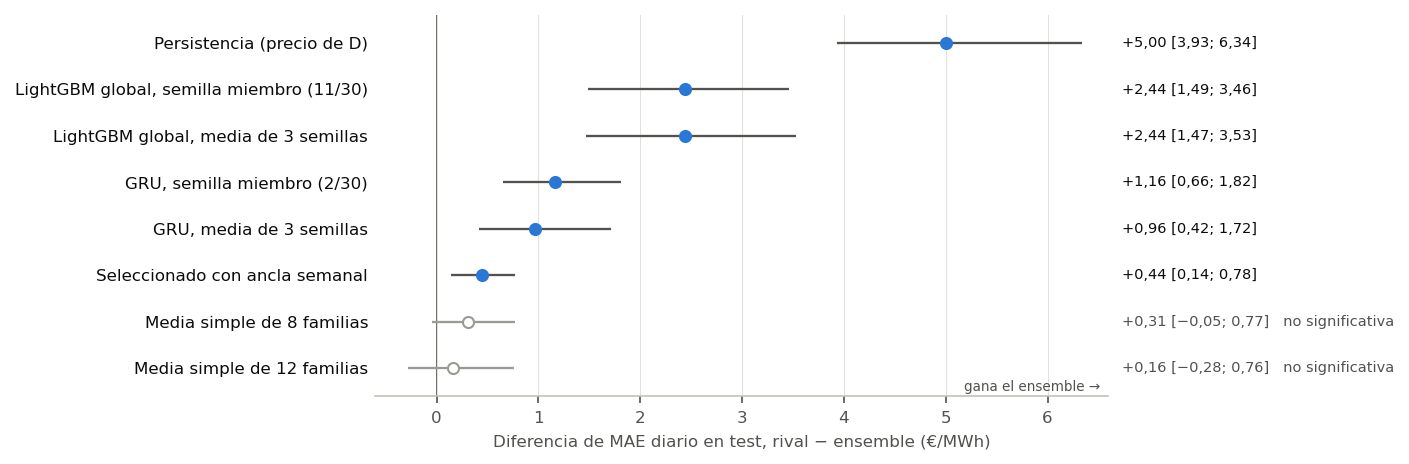

In [10]:
orden_r = c.sort_values("dif_media_rival_menos_sel").index        # arriba, la mayor ventaja
with plt.rc_context(RC):
    fig, ax = plt.subplots(figsize=(16 / 2.54, 0.9 + 0.3 * len(orden_r)), dpi=DPI)
    trans = blended_transform_factory(ax.transAxes, ax.transData)
    for yy, k in enumerate(orden_r):
        r = c.loc[k]
        sig = bool(r.IC_excluye_0)
        ax.hlines(yy, r.IC95_inf, r.IC95_sup, color=TINTA_2 if sig else GRIS, lw=1.1, zorder=2)
        ax.scatter(r.dif_media_rival_menos_sel, yy, s=28, zorder=3, lw=1,
                   facecolor=BARRA if sig else "white", edgecolor=BARRA if sig else GRIS)
        ax.text(1.02, yy, intervalo(k) + ("" if sig else "   no significativa"), transform=trans,
                va="center", ha="left", fontsize=7, color=TINTA if sig else TINTA_2)
    ax.axvline(0, color=TINTA_2, lw=0.8, zorder=1)
    ax.set_yticks(range(len(orden_r)), [ETQ_RIVAL.get(k, k) for k in orden_r])
    ax.set_ylim(-0.6, len(orden_r) - 0.4)
    ax.set_xlim(min(-0.6, c.IC95_inf.min() - 0.2), c.IC95_sup.max() * 1.04)
    ax.xaxis.set_major_formatter(EJE_COMA)
    ax.set_xlabel("Diferencia de MAE diario en test, rival − ensemble (€/MWh)")
    ax.grid(axis="x", color=REJILLA, lw=0.5, zorder=0)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.text(0.99, -0.55, "gana el ensemble →", ha="right", va="bottom", fontsize=6.5, color=TINTA_2,
            transform=trans)
    plt.show()

## 4 · Aportación de cada miembro y correlación de errores

**Aportación.** Se quita un miembro, se renormalizan los pesos del resto y se mide el MAE; `Δ` es el cambio respecto al ensemble completo (positivo: el miembro ayudaba). Se añaden el MAE del miembro solo y, como referencia, los seis miembros a pesos iguales. **Cómo leerla:** un miembro aporta en test si su `Δ test` es claramente positivo; si solo lo es en validación, su peso refleja sobre todo el ajuste a 2025.

La celda repite estos MAE desde las predicciones guardadas y busca en el informe las dos cifras que cita.

In [11]:
P = {"val": {k: leer(DIR_D, f"pred_val_{k}") for k in PESOS}, "test": {k: leer(DIR_D, f"pred_test_{k}") for k in PESOS}}
Y = {"val": YV, "test": YT}


def mae_mezcla(parte, pesos):
    tot = sum(pesos.values())
    return float(np.abs(sum(P[parte][k] * w / tot for k, w in pesos.items()) - Y[parte]).mean())


variantes = {"(ninguno: seleccion completa)": dict(cuenta)}
variantes.update({k: {j: v for j, v in cuenta.items() if j != k} for k in PESOS})
variantes["(referencia: los 6 miembros con pesos iguales)"] = {k: 1 for k in PESOS}
rep_ap = pd.DataFrame({q: {"MAE_val": mae_mezcla("val", w), "MAE_test": mae_mezcla("test", w)}
                       for q, w in variantes.items()}).T
a = aport.set_index("quitado")
err = (rep_ap - a[["MAE_val", "MAE_test"]]).abs().max().max()
comprobar("aportación recalculada desde predicciones = aportacion_miembros.csv", err < 0.001, f"máx. {err:.4f}")

ETQ_Q = {"(ninguno: seleccion completa)": "Ensemble completo (6 miembros)",
         "(referencia: los 6 miembros con pesos iguales)": "Seis miembros a pesos iguales (5/30 cada uno)"}
ETQ_Q.update({k: f"Sin {MIEMBRO[k]} ({cuenta[k]}/30)" for k in PESOS})
vista_ap = pd.DataFrame({"variante": [ETQ_Q[q] for q in a.index], "MAE val": a.MAE_val, "MAE test": a.MAE_test,
                         "Δ val": a.delta_val, "Δ test": a.delta_test,
                         "MAE val miembro solo": a.MAE_val_miembro_solo,
                         "MAE test miembro solo": a.MAE_test_miembro_solo})
display(vista_ap.style.hide(axis="index").format(precision=3, na_rep="—"))

sin_l, sin_d = a.loc["lgbm_nucleo__s1"], a.loc["denso__s2"]
otros = a.loc[[k for k in PESOS if k not in ("lgbm_nucleo__s1", "denso__s2")]]
print(f"sin LightGBM global: val {coma(sin_l.MAE_val)} · test {coma(sin_l.MAE_test)}   |   "
      f"sin red densa: val {coma(sin_d.MAE_val)} · test {coma(sin_d.MAE_test)}")
print("los otros cuatro, Δ test: " + ", ".join(f"{MIEMBRO[k]} {coma(r.delta_test, 3, True)}"
                                              for k, r in otros.iterrows()))
iguales = a.iloc[-1]
print(f"pesos iguales: val {coma(iguales.MAE_val)} · test {coma(iguales.MAE_test)}")
texto = f"{coma(sin_l.MAE_test)} y {coma(sin_d.MAE_test)}"
comprobar(f"«sube a {texto}» en el informe", f"sube a {texto}" in INFORME)
comprobar("los otros cuatro apenas cambian el test (|Δ test| < 0,1)", otros.delta_test.abs().max() < 0.1,
          f"máx. {coma(otros.delta_test.abs().max(), 3)}")

[ok] aportación recalculada desde predicciones = aportacion_miembros.csv · máx. 0.0005


variante,MAE val,MAE test,Δ val,Δ test,MAE val miembro solo,MAE test miembro solo
Ensemble completo (6 miembros),11.732,11.724,0.000,0.000,—,—
Sin LightGBM global (11/30),12.270,12.704,0.538,0.980,13.008,14.164
Sin Red densa (10/30),11.984,12.179,0.252,0.455,12.843,13.466
Sin LSTM (3/30),11.750,11.684,0.018,-0.040,13.296,15.778
Sin Seq2seq precio absoluto (3/30),11.787,11.712,0.055,-0.011,15.401,15.276
Sin GRU (2/30),11.744,11.805,0.012,0.082,14.052,12.886
Sin Seq2seq residual (1/30),11.733,11.748,0.001,0.024,13.966,13.277
Seis miembros a pesos iguales (5/30 cada uno),12.030,11.922,0.298,0.199,—,—


sin LightGBM global: val 12,27 · test 12,70   |   sin red densa: val 11,98 · test 12,18
los otros cuatro, Δ test: LSTM −0,040, Seq2seq precio absoluto −0,011, GRU +0,082, Seq2seq residual +0,024
pesos iguales: val 12,03 · test 11,92
[ok] «sube a 12,70 y 12,18» en el informe
[ok] los otros cuatro apenas cambian el test (|Δ test| < 0,1) · máx. 0,082


**Correlación de errores en validación.** Correlación de Pearson entre los errores horarios (predicción − real) de cada par de miembros en 2025. **Cómo leerla:** cuanto más clara la celda, menos se parecen los errores y más diversifica la mezcla (escala de 0,5 a 1). Se muestra solo el triángulo inferior (la matriz es simétrica); entre paréntesis, el peso de cada miembro.

[ok] correlación recalculada desde predicciones = correlacion_errores_val.csv · máx. 0.0005
media de los 15 pares: 0,752 · mínimo 0,597 (Seq2seq precio absoluto con LightGBM global) · máximo 0,927 (Seq2seq residual con GRU)
en test (cifras_decision.json): media 0,706
[ok] media, mínimo y máximo = cifras_decision.json


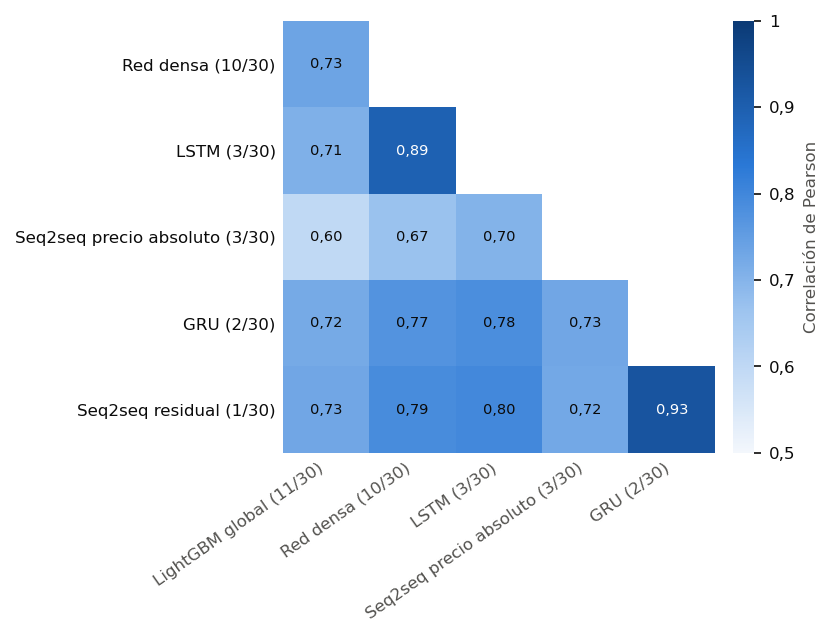

In [12]:
E = pd.DataFrame({k: (P["val"][k] - YV).ravel() for k in corr.index})
err = (E.corr() - corr).abs().max().max()
comprobar("correlación recalculada desde predicciones = correlacion_errores_val.csv", err < 0.001, f"máx. {err:.4f}")

M = corr.to_numpy()
nm = len(M)
tri = M[np.tril_indices(nm, -1)]
pares = corr.where(np.tril(np.ones(M.shape, bool), -1)).stack()
p_min, p_max = pares.idxmin(), pares.idxmax()
print(f"media de los {len(tri)} pares: {coma(tri.mean(), 3)} · mínimo {coma(tri.min(), 3)} "
      f"({MIEMBRO[p_min[0]]} con {MIEMBRO[p_min[1]]}) · máximo {coma(tri.max(), 3)} "
      f"({MIEMBRO[p_max[0]]} con {MIEMBRO[p_max[1]]})")
print(f"en test (cifras_decision.json): media {coma(cifras['correlacion_errores']['media_pares_test'], 3)}")
ce = cifras["correlacion_errores"]
comprobar("media, mínimo y máximo = cifras_decision.json",
          abs(ce["media_pares_val"] - tri.mean()) < 6e-4 and ce["min_val"] == tri.min() and ce["max_val"] == tri.max())

etq = [f"{MIEMBRO[k]} ({cuenta[k]}/30)" for k in corr.index]
cmap = LinearSegmentedColormap.from_list("azul", ["#f3f7fc", "#9cc3ef", BARRA, "#0b3a75"])
with plt.rc_context(RC):
    fig, ax = plt.subplots(figsize=(13 / 2.54, 9.5 / 2.54), dpi=DPI)
    im = ax.imshow(np.ma.masked_array(M, np.triu(np.ones(M.shape, bool))), cmap=cmap, vmin=0.5, vmax=1.0)
    for i in range(nm):
        for j in range(i):
            ax.text(j, i, coma(M[i, j]), ha="center", va="center", fontsize=7,
                    color="white" if M[i, j] > 0.84 else TINTA)
    ax.set_xticks(range(nm - 1), etq[:-1], rotation=35, ha="right")
    ax.set_yticks(range(1, nm), etq[1:])
    ax.set_xlim(-0.5, nm - 1.5)
    ax.set_ylim(nm - 0.5, 0.5)
    ax.tick_params(length=0)
    for lado in ax.spines.values():
        lado.set_visible(False)
    cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, format=EJE_COMA)
    cb.outline.set_visible(False)
    cb.set_label("Correlación de Pearson", color=TINTA_2)
    plt.show()

## 5 · Figura de decisión: MAE de validación frente a MAE de test

> **Material de apoyo.** Esta figura (`fig_decision.png`) se descartó del informe; se conserva porque resume la tabla completa en una sola vista. El código de dibujo es el de la función `figura` de `tabla_decision.py`, copiado sin cambios salvo que muestra la figura en lugar de guardarla (importar el script cargaría `scripts/entrenar_finales*.py` y fijaría el backend `Agg`).

**Cómo leerla:** cada punto es un modelo, con su MAE de validación en el eje horizontal y el de test en el vertical. La diagonal punteada es «val = test»: por debajo, el modelo lo hizo mejor en test que en validación. La estrella roja es el modelo final (abajo a la izquierda: el mejor en ambos); los puntos azules son las familias miembro con su peso; las cruces, ±1 desviación entre semillas. La línea discontinua superior es la persistencia en test. Los modelos fuera de escala se listan abajo a la derecha.

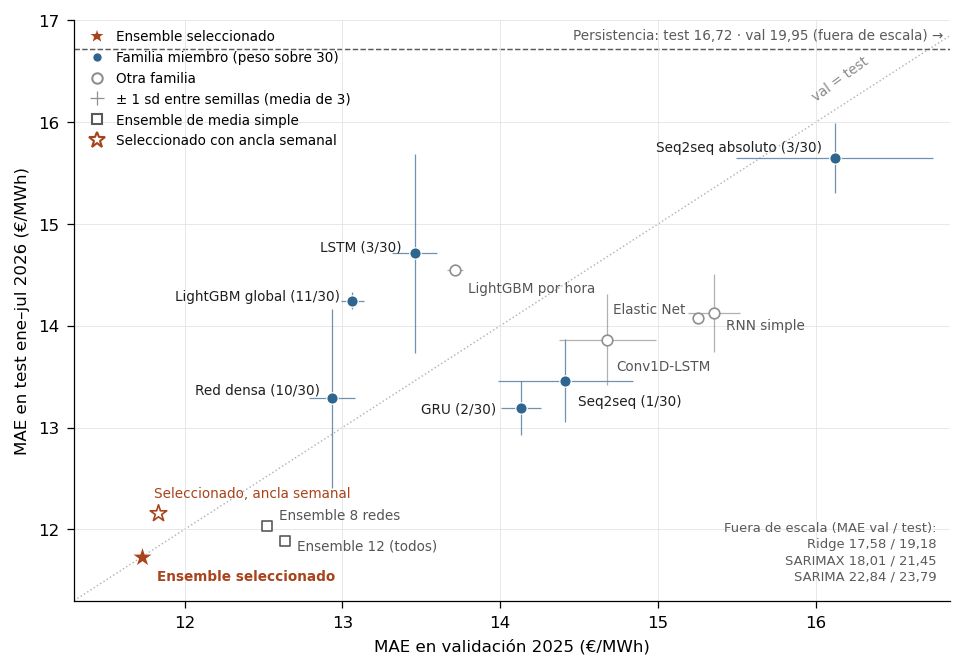

peor en test que en validación: Ensemble seleccionado con ancla semanal (descartado), Red densa, LightGBM global, LSTM, LightGBM por hora (24 modelos), Ridge, SARIMAX, SARIMA


In [13]:
def figura_decision(tabla):
    """`figura` de docs/interpretabilidad/tabla_decision.py, con plt.show() en lugar de savefig."""
    C_SEL, C_MIE, C_OTRO, C_REF = "#a8431c", "#2f6690", "#8f8f8f", "#5a5a5a"
    ETQ = {"denso": "Red densa", "lgbm_nucleo": "LightGBM global", "lstm": "LSTM",
           "boosting": "LightGBM por hora", "gru": "GRU", "seq2seq": "Seq2seq",
           "conv1d_lstm": "Conv1D-LSTM", "elasticnet": "Elastic Net", "simplernn": "RNN simple",
           "seq2seq_absoluto": "Seq2seq absoluto", "ridge": "Ridge", "sarimax": "SARIMAX",
           "sarima": "SARIMA", "ensemble_seleccion": "Ensemble seleccionado",
           "ensemble": "Ensemble 8 redes", "ensemble_todos": "Ensemble 12 (todos)",
           "ensemble_seleccion_anclasemanal": "Seleccionado, ancla semanal"}
    # desplazamiento de la etiqueta en puntos (dx, dy, alineacion)
    OFF = {"ensemble_seleccion": (7, -9, "left"), "ensemble": (6, 5, "left"),
           "ensemble_todos": (6, -2, "left"), "ensemble_seleccion_anclasemanal": (-2, 9, "left"),
           "denso": (-6, 4, "right"), "lgbm_nucleo": (-6, 2, "right"), "lstm": (-6, 3, "right"),
           "boosting": (6, -9, "left"), "gru": (-12, 0, "right"), "seq2seq": (6, -10, "left"),
           "conv1d_lstm": (4, -13, "left"), "elasticnet": (-6, 4, "right"),
           "simplernn": (6, -6, "left"), "seq2seq_absoluto": (-6, 5, "right")}
    X0, X1, Y0, Y1 = 11.3, 16.85, 11.3, 17.0

    fig, ax = plt.subplots(figsize=(16 / 2.54, 11 / 2.54), dpi=DPI)
    ax.plot([X0, X1], [X0, X1], ls=":", lw=0.7, color="#b5b5b5", zorder=0)
    ax.text(16.35, 16.18, "val = test", color="#8a8a8a", fontsize=6.5, rotation=36,
            ha="right", va="bottom")
    naive = tabla.loc["naive (persistencia)"]
    ax.axhline(naive.MAE_test, ls="--", lw=0.7, color=C_REF, zorder=0)
    ax.annotate(f"Persistencia: test {naive.MAE_test:.2f} · val {naive.MAE_val:.2f} (fuera de escala) →"
                .replace(".", ","), xy=(X1, naive.MAE_test), xytext=(-3, 3),
                textcoords="offset points", ha="right", va="bottom", fontsize=6.5, color=C_REF)

    fuera = []
    for k, r in tabla.iterrows():
        if k == "naive (persistencia)":
            continue
        if r.MAE_val > X1 or r.MAE_test > Y1:
            fuera.append(f"{ETQ[k]} {r.MAE_val:.2f} / {r.MAE_test:.2f}".replace(".", ","))
            continue
        es_ens = r.tipo == "ensemble"
        if k == "ensemble_seleccion":
            kw = dict(marker="*", s=120, facecolor=C_SEL, edgecolor="white", lw=0.6, zorder=5)
        elif k == "ensemble_seleccion_anclasemanal":
            kw = dict(marker="*", s=70, facecolor="white", edgecolor=C_SEL, lw=0.8, zorder=4)
        elif es_ens:
            kw = dict(marker="s", s=26, facecolor="white", edgecolor=C_REF, lw=0.8, zorder=4)
        elif r.miembro_seleccion == "si":
            kw = dict(marker="o", s=30, facecolor=C_MIE, edgecolor="white", lw=0.6, zorder=4)
        else:
            kw = dict(marker="o", s=26, facecolor="white", edgecolor=C_OTRO, lw=0.8, zorder=3)
        if not es_ens and pd.notna(r.sd_val):
            col = C_MIE if r.miembro_seleccion == "si" else C_OTRO
            ax.errorbar(r.MAE_val, r.MAE_test, xerr=r.sd_val, yerr=r.sd_test, fmt="none",
                        ecolor=col, elinewidth=0.6, alpha=0.7, zorder=2)
        ax.scatter(r.MAE_val, r.MAE_test, **kw)
        txt = ETQ[k] + (f" ({r.peso_de_30})" if r.miembro_seleccion == "si" else "")
        dx, dy, ha = OFF.get(k, (6, 0, "left"))
        color = C_SEL if k.startswith("ensemble_seleccion") else (
            "#1f1f1f" if r.miembro_seleccion == "si" or k == "ensemble_seleccion" else "#555555")
        ax.annotate(txt, (r.MAE_val, r.MAE_test), xytext=(dx, dy), textcoords="offset points",
                    ha=ha, va="center", fontsize=6.5, color=color,
                    fontweight="bold" if k == "ensemble_seleccion" else "normal")

    ax.text(0.985, 0.03, "Fuera de escala (MAE val / test):\n" + "\n".join(fuera),
            transform=ax.transAxes, ha="right", va="bottom", fontsize=6.3, color=C_REF,
            linespacing=1.35)
    ax.set_xlim(X0, X1)
    ax.set_ylim(Y0, Y1)
    fmt = FuncFormatter(lambda v, _: f"{v:.0f}" if float(v).is_integer() else f"{v:.1f}".replace(".", ","))
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    ax.set_xlabel("MAE en validación 2025 (€/MWh)")
    ax.set_ylabel("MAE en test ene–jul 2026 (€/MWh)")
    ax.grid(True, lw=0.4, color="#e4e4e4", zorder=-1)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    h = [Line2D([], [], marker="*", ls="", ms=10, mfc=C_SEL, mec="white", label="Ensemble seleccionado"),
         Line2D([], [], marker="o", ls="", ms=5, mfc=C_MIE, mec="white", label="Familia miembro (peso sobre 30)"),
         Line2D([], [], marker="o", ls="", ms=5, mfc="white", mec=C_OTRO, label="Otra familia"),
         Line2D([], [], marker="+", ls="", ms=7, mew=0.6, color=C_OTRO, label="± 1 sd entre semillas (media de 3)"),
         Line2D([], [], marker="s", ls="", ms=4.5, mfc="white", mec=C_REF, label="Ensemble de media simple"),
         Line2D([], [], marker="*", ls="", ms=8, mfc="white", mec=C_SEL, label="Seleccionado con ancla semanal")]
    ax.legend(handles=h, loc="upper left", frameon=False, fontsize=6.5, handletextpad=0.4,
              borderaxespad=0.3)
    fig.tight_layout(pad=0.3)
    plt.show()


with plt.rc_context({"font.size": 8, "font.family": "DejaVu Sans", "axes.linewidth": 0.6,
                     "xtick.major.width": 0.6, "ytick.major.width": 0.6}):
    figura_decision(tabla)

sobre_diag = [NOMBRE[k] for k, r in tabla.drop("naive (persistencia)").iterrows() if r.MAE_test > r.MAE_val]
print("peor en test que en validación:", ", ".join(sobre_diag))

## 6 · Salvedades

Las mismas que declara el informe; las cifras citadas se han comprobado en las secciones anteriores.

- **La validación es optimista para los ensembles seleccionados.** Miembros y pesos se ajustaron sobre 2025, así que su MAE de validación (11,73 y 11,83) es consecuencia del procedimiento y no un mérito; la medida honesta es el test. La curva de selección es plana (11,736 en el paso 10, 11,732 en el 30, con el mínimo en el límite de pasos), de modo que los pesos pequeños (GRU 2/30, seq2seq residual 1/30) están poco determinados (sección 2).
- **Frente a las medias simples, la ventaja en test no es significativa.** +0,16 [−0,28; 0,76] frente a la de 12 familias y +0,31 [−0,05; 0,77] frente a la de 8. La preferencia por la selección descansa en el criterio de validación fijado de antemano, no en el test (sección 3). Sí es significativa frente a la persistencia, a sus miembros más fuertes y a la variante con ancla semanal.
- **La regla de combinación cambió después de ver el test.** La regla anterior promediaba las familias que batían a la persistencia en validación; incluía Ridge y SARIMAX, que la baten en validación (17,58 y 18,01 frente a 19,95) pero no en test (19,18 y 21,45 frente a 16,72), y se sustituyó por la selección voraz tras verlo. El test no es del todo independiente para comparar selección y media simple (sección 1.2).
- **Menor MAE no es mejor orden horario.** La media de 12 familias acierta más el pico (78,3 % frente a 76,4 %), y el seq2seq de precio absoluto y Ridge llegan al 81,4 % y 81,6 %. La selección optimiza el MAE; ni la captura ni el pico llevan contraste de incertidumbre.
- **Las previsiones de REE para D+1 están revisadas.** Se cargaron con valores ya revisados en validación y test, así que el MAE de test (11,72 €/MWh) y la mejora del 29,9 % pueden ser optimistas frente a producción, donde solo existe la previsión disponible a las 11:00 de D. Queda pendiente medirlo reentrenando sin esas variables.

In [14]:
pico = {k: medir(k)["pico_1h"] for k in ("seq2seq_absoluto", "ridge")}
texto_pico = (f"{coma(rec.loc['ensemble_todos', 'pico_1h'], 1)} % frente a {coma(rec.loc['ensemble_seleccion', 'pico_1h'], 1)} %")
texto_abs = f"{coma(pico['seq2seq_absoluto'], 1)} % y {coma(pico['ridge'], 1)} %"
comprobar(f"pico: «{texto_pico}» en el informe", texto_pico in INFORME)
comprobar(f"pico: «{texto_abs}» en el informe", texto_abs in INFORME)

print(f"\nResumen: {sum(ok for _, ok in COMPROBACIONES)} de {len(COMPROBACIONES)} comprobaciones correctas")
for nombre, ok in COMPROBACIONES:
    if not ok:
        print("  FALLA:", nombre)
assert all(ok for _, ok in COMPROBACIONES), "alguna cifra no coincide con el informe o con los CSV"

[ok] pico: «78,3 % frente a 76,4 %» en el informe
[ok] pico: «81,4 % y 81,6 %» en el informe

Resumen: 33 de 33 comprobaciones correctas
